🟦 BLOCK 1 — Install & Setup Environment
📌 What this does:
Installs required libraries in Google Colab
Sets backend for Keras (important for ViT model)

In [1]:
# =========================
# BLOCK 1: ENVIRONMENT SETUP
# =========================

# Install required libraries (run this first in Colab)
!pip install -U keras opencv-python scipy matplotlib

# -------------------------
# IMPORTANT:
# We set backend to TensorFlow (recommended for Colab GPU)
# Options: "tensorflow", "jax", "torch"
# -------------------------
import os
os.environ["KERAS_BACKEND"] = "tensorflow"


🟦 BLOCK 2 — Import Libraries
📌 What this does:

Loads all required Python libraries for:

deep learning (Keras)
image processing (OpenCV, PIL)
math + plotting

In [2]:
# =========================
# BLOCK 2: IMPORTS
# =========================

import numpy as np
import keras
from keras import layers
from keras import ops

import matplotlib.pyplot as plt
import cv2
import scipy.io
import shutil


🟦 BLOCK 3 — Download Dataset (Caltech 101)
📌 What this does:
Downloads dataset automatically
Extracts images + annotations

In [4]:
# =========================
# BLOCK 3: DOWNLOAD DATASET (FIXED VERSION)
# =========================

import os
import keras

# Download and extract dataset automatically
path_to_downloaded_file = keras.utils.get_file(
    fname="caltech_101",
    origin="https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip",
    extract=True,
    cache_dir="./"
)

# Get extracted folder path
base_dir = os.path.join("./datasets", "caltech-101")

print("Dataset extracted at:", base_dir)

# -------------------------
# IMPORTANT:
# DO NOT unpack tar.gz manually
# Colab already extracts it properly
# -------------------------


137414764/137414764 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Dataset extracted at: ./datasets/caltech-101


🟦 BLOCK 4 — Load Images + Bounding Boxes
📌 What this does:
Reads images
Reads annotation (bounding boxes)
Normalizes coordinates (0 → 1 range)

In [13]:
# =========================
# BLOCK 3.5: EXTRACT TAR FILES (CRITICAL STEP)
# =========================

import os
import shutil

base_path = "./datasets/caltech_101/caltech-101"

# Paths to compressed files
images_tar = os.path.join(base_path, "101_ObjectCategories.tar.gz")
annot_tar = os.path.join(base_path, "Annotations.tar")

print("Images tar exists:", os.path.exists(images_tar))
print("Annotations tar exists:", os.path.exists(annot_tar))

# Extract images
shutil.unpack_archive(images_tar, "./datasets/caltech_101/")

# Extract annotations
shutil.unpack_archive(annot_tar, "./datasets/caltech_101/")

print("Extraction complete!")


Images tar exists: True
Annotations tar exists: True
Extraction complete!


Verify extraction worked

In [14]:
import os

for root, dirs, files in os.walk("./datasets/caltech_101"):
    if "ObjectCategories" in root or "Annotations" in root:
        print("ROOT:", root)
        print("SAMPLE FILES:", files[:3])
        print("-" * 60)



ROOT: ./datasets/caltech_101/Annotations
SAMPLE FILES: ['README~', 'check_progress.mat', 'FeatureDetectionQuality.mat']
------------------------------------------------------------
ROOT: ./datasets/caltech_101/Annotations/octopus
SAMPLE FILES: ['annotation_0033.mat', 'annotation_0017.mat', 'annotation_0015.mat']
------------------------------------------------------------
ROOT: ./datasets/caltech_101/Annotations/dalmatian
SAMPLE FILES: ['annotation_0033.mat', 'annotation_0045.mat', 'annotation_0037.mat']
------------------------------------------------------------
ROOT: ./datasets/caltech_101/Annotations/cougar_face
SAMPLE FILES: ['annotation_0033.mat', 'annotation_0045.mat', 'annotation_0037.mat']
------------------------------------------------------------
ROOT: ./datasets/caltech_101/Annotations/mandolin
SAMPLE FILES: ['annotation_0033.mat', 'annotation_0037.mat', 'annotation_0041.mat']
------------------------------------------------------------
ROOT: ./datasets/caltech_101/Annotat

In [16]:
import os

for root, dirs, files in os.walk("./datasets/caltech_101"):
    if "Airplane" in root or "airplane" in root.lower():
        print("FOUND:", root)


FOUND: ./datasets/caltech_101/Annotations/Airplanes_Side_2
FOUND: ./datasets/caltech_101/101_ObjectCategories/airplanes


In [17]:
# =========================
# BLOCK 4: LOAD DATA (FINAL WORKING VERSION)
# =========================

import os
import numpy as np
import keras
import scipy.io

# ✅ Correct paths (confirmed by your output)
path_images = "./datasets/caltech_101/101_ObjectCategories/airplanes/"
path_annot = "./datasets/caltech_101/Annotations/Airplanes_Side_2/"

# -------------------------
# Safety checks
# -------------------------
print("Images path exists:", os.path.exists(path_images))
print("Annotation path exists:", os.path.exists(path_annot))

# Load file lists
image_paths = sorted(os.listdir(path_images))
annot_paths = sorted(os.listdir(path_annot))

print("Number of images:", len(image_paths))
print("Number of annotations:", len(annot_paths))

image_size = 224

images = []
targets = []

# -------------------------
# Load images + bounding boxes
# -------------------------
for i in range(len(annot_paths)):

    # Load annotation (.mat file)
    annot = scipy.io.loadmat(path_annot + annot_paths[i])["box_coord"][0]

    top_left_x, top_left_y = annot[2], annot[0]
    bottom_right_x, bottom_right_y = annot[3], annot[1]

    # Load image
    image = keras.utils.load_img(path_images + image_paths[i])
    w, h = image.size

    # Resize image
    image = image.resize((image_size, image_size))
    image = keras.utils.img_to_array(image)

    images.append(image)

    # Normalize bounding box (VERY IMPORTANT for training stability)
    targets.append([
        top_left_x / w,
        top_left_y / h,
        bottom_right_x / w,
        bottom_right_y / h
    ])

# Convert to numpy arrays
images = np.array(images)
targets = np.array(targets)

print("Dataset loaded successfully!")
print("Images shape:", images.shape)
print("Targets shape:", targets.shape)


Images path exists: True
Annotation path exists: True
Number of images: 800
Number of annotations: 800
Dataset loaded successfully!
Images shape: (800, 224, 224, 3)
Targets shape: (800, 4)


In [21]:
# =========================
# BLOCK 5: TRAIN-TEST SPLIT
# =========================

split = int(len(images) * 0.8)

x_train = images[:split]
y_train = targets[:split]

x_test = images[split:]
y_test = targets[split:]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: (640, 224, 224, 3)
y_train shape: (640, 4)


🟦 BLOCK 6 — Patch Extraction (ViT CORE IDEA)
📌 What this does (important concept)

ViT does NOT see the full image at once.

Instead:

It splits image into small patches (e.g., 32×32)
Each patch becomes a “token” (like words in NLP)
Transformer processes these tokens

In [19]:
# =========================
# BLOCK 6: PATCH EXTRACTION LAYER
# =========================

import keras
from keras import layers
from keras import ops
import numpy as np

# -------------------------
# This layer splits image into patches
# Example:
# 224x224 image with 32x32 patches → 7x7 = 49 patches
# -------------------------
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        # images shape: (batch, height, width, channels)
        batch_size = ops.shape(images)[0]
        height = ops.shape(images)[1]
        width = ops.shape(images)[2]
        channels = ops.shape(images)[3]

        # number of patches in each dimension
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size

        # extract patches using keras utility
        patches = keras.ops.image.extract_patches(
            images,
            size=self.patch_size
        )

        # reshape into (batch, num_patches, patch_vector)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels
            )
        )

        return patches


🟦 BLOCK 7 — Visualize Patches (VERY IMPORTANT)
📌 What this does
Shows how image is split
Helps you understand ViT behavior

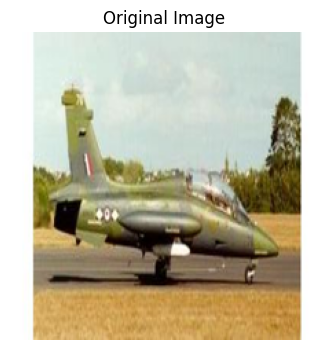

Patch shape: (1, 49, 3072)


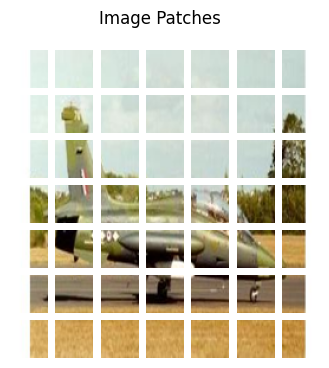

In [22]:
# =========================
# BLOCK 7: VISUALIZE PATCHES
# =========================

import matplotlib.pyplot as plt

patch_size = 32

# Take one image
image = x_train[0]

plt.figure(figsize=(4,4))
plt.imshow(image.astype("uint8"))
plt.title("Original Image")
plt.axis("off")
plt.show()

# Create patch layer
patch_layer = Patches(patch_size)

# Add batch dimension
img_batch = np.expand_dims(image, axis=0)

# Get patches
patches = patch_layer(img_batch)

print("Patch shape:", patches.shape)

# number of patches per row/column
n = int(np.sqrt(patches.shape[1]))

plt.figure(figsize=(4,4))

for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i+1)

    patch_img = ops.reshape(patch, (patch_size, patch_size, 3))

    plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
    plt.axis("off")

plt.suptitle("Image Patches")
plt.show()


🟦 BLOCK 8 — MLP Helper Function
📌 What this does

This is a small neural network used inside the Transformer.

It processes patch features
Adds non-linearity
Helps model learn complex patterns

In [23]:
# =========================
# BLOCK 8: MLP FUNCTION
# =========================

from keras import layers
import keras

def mlp(x, hidden_units, dropout_rate):
    """
    Multi-Layer Perceptron used inside Transformer blocks

    Args:
        x: input tensor
        hidden_units: list like [128, 64]
        dropout_rate: dropout probability
    """

    for units in hidden_units:
        # Fully connected layer
        x = layers.Dense(units, activation=keras.activations.gelu)(x)

        # Dropout for regularization (prevents overfitting)
        x = layers.Dropout(dropout_rate)(x)

    return x


🟦 BLOCK 9 — Patch Encoder (CORE ViT COMPONENT)
📌 What this does

This is where patches become meaningful tokens.

It does 2 things:

1. Linear Projection

Converts patch → feature vector

In [24]:
# =========================
# BLOCK 9: PATCH ENCODER
# =========================

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()

        # total number of patches
        self.num_patches = num_patches

        # converts patch vector → embedding vector
        self.projection = layers.Dense(projection_dim)

        # learnable position embedding
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):

        # create position indices: [0, 1, 2, ...]
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1),
            axis=0
        )

        # project patch into embedding space
        projected_patches = self.projection(patch)

        # add position information
        encoded = projected_patches + self.position_embedding(positions)

        return encoded


BLOCK 10 — TRANSFORMER BLOCK (ViT CORE)
📌 What this block does

Each transformer layer does:

1. Layer Normalization

Stabilizes learning

2. Multi-Head Self Attention

Lets patches “look at” each other

3. Skip Connections

Prevents gradient vanishing

4. MLP (Feed Forward Network)

Learns deeper feature interactions

In [25]:
# =========================
# BLOCK 10: TRANSFORMER BLOCK
# =========================

from keras import layers

def transformer_block(x, num_heads, projection_dim, transformer_units, dropout_rate=0.1):
    """
    One Vision Transformer encoder block
    """

    # -------------------------
    # 1. Layer Normalization (input stabilization)
    # -------------------------
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)

    # -------------------------
    # 2. Multi-Head Self Attention
    # -------------------------
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim,
        dropout=dropout_rate
    )(x1, x1)

    # -------------------------
    # 3. Skip connection (Residual)
    # -------------------------
    x2 = layers.Add()([attention_output, x])

    # -------------------------
    # 4. Second Layer Normalization
    # -------------------------
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

    # -------------------------
    # 5. Feed Forward Network (MLP)
    # -------------------------
    x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=dropout_rate)

    # -------------------------
    # 6. Second Skip connection
    # -------------------------
    output = layers.Add()([x3, x2])

    return output


🟦 BLOCK 11 — FULL ViT OBJECT DETECTOR MODEL
📌 What this model does

It takes an image and:

Splits into patches
Converts patches into embeddings
Applies multiple transformer blocks
Learns global relationships

In [26]:
# =========================
# BLOCK 11: FULL VIT MODEL
# =========================

import keras
from keras import layers

def create_vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units
):

    # -------------------------
    # INPUT IMAGE
    # -------------------------
    inputs = keras.Input(shape=input_shape)

    # -------------------------
    # STEP 1: PATCH EXTRACTION
    # -------------------------
    patches = Patches(patch_size)(inputs)

    # -------------------------
    # STEP 2: PATCH ENCODING (projection + position embedding)
    # -------------------------
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # -------------------------
    # STEP 3: TRANSFORMER ENCODER STACK
    # -------------------------
    for _ in range(transformer_layers):
        encoded_patches = transformer_block(
            encoded_patches,
            num_heads=num_heads,
            projection_dim=projection_dim,
            transformer_units=transformer_units
        )

    # -------------------------
    # STEP 4: FINAL REPRESENTATION
    # -------------------------
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

    # Flatten sequence of patches into vector
    representation = layers.Flatten()(representation)

    # Regularization
    representation = layers.Dropout(0.3)(representation)

    # -------------------------
    # STEP 5: MLP HEAD (FINAL FEATURE LEARNING)
    # -------------------------
    features = mlp(representation, mlp_head_units, dropout_rate=0.3)

    # -------------------------
    # STEP 6: BOUNDING BOX OUTPUT
    # -------------------------
    bounding_box = layers.Dense(4, activation="sigmoid")(features)

    # -------------------------
    # CREATE MODEL
    # -------------------------
    model = keras.Model(inputs=inputs, outputs=bounding_box)

    return model


🟦 BLOCK 12 — TRAINING FUNCTION

You will get:

optimizer (AdamW)
loss function (MSE)
checkpoint saving
early stopping
full training loop

In [27]:
# =========================
# BLOCK 12: TRAINING FUNCTION
# =========================

import keras

def run_experiment(model, learning_rate, weight_decay, batch_size, num_epochs):

    # -------------------------
    # 1. OPTIMIZER
    # AdamW = Adam + Weight Decay (better generalization)
    # -------------------------
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=weight_decay
    )

    # -------------------------
    # 2. COMPILE MODEL
    # Loss = Mean Squared Error (for bounding box regression)
    # -------------------------
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.MeanSquaredError()
    )

    # -------------------------
    # 3. SAVE BEST MODEL ONLY
    # -------------------------
    checkpoint_filepath = "vit_object_detector.weights.h5"

    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    # -------------------------
    # 4. EARLY STOPPING
    # Stops training if model stops improving
    # -------------------------
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # -------------------------
    # 5. TRAIN MODEL
    # -------------------------
    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[checkpoint_callback, early_stop],
        shuffle=True
    )

    return history


🟦 BLOCK 13 — TRAIN MODEL + EVALUATION (IoU + VISUALIZATION)
📌 What this block does
✔ Creates model
✔ Trains ViT
✔ Plots loss curves
✔ Evaluates bounding box quality (IoU)
✔ Visualizes predictions vs ground truth

Model created successfully!
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0794
Epoch 1: val_loss improved from None to 0.03236, saving model to vit_object_detector.weights.h5

Epoch 1: finished saving model to vit_object_detector.weights.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 213ms/step - loss: 0.0546 - val_loss: 0.0324
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0394
Epoch 2: val_loss did not improve from 0.03236
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0397 - val_loss: 0.0324
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0395
Epoch 3: val_loss did not improve from 0.03236
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0403 - val_loss: 0.0324
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0386
Epoch 4: val_loss did not improve from 0.03236
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0373 - val_loss: 0.0324
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0396
Epoch 5: val_loss did not improve from 0.

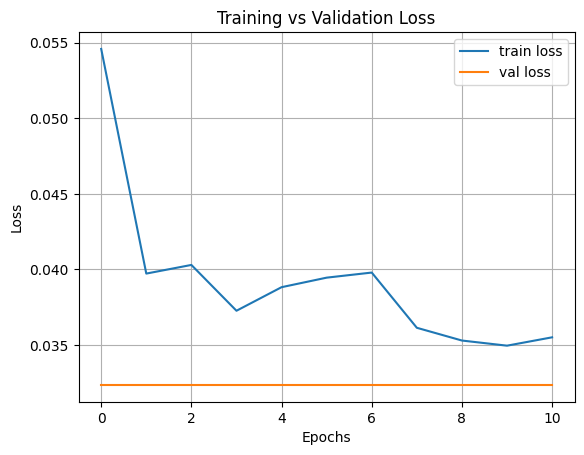

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


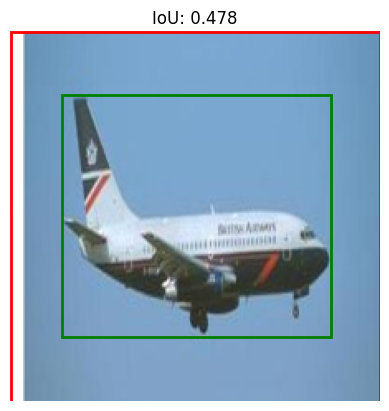

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


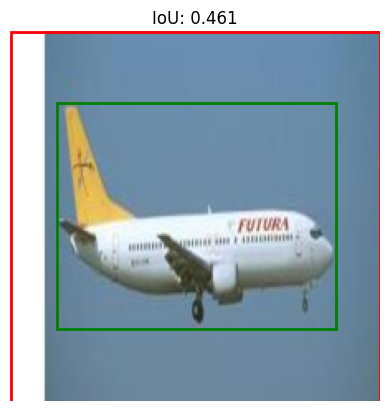

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


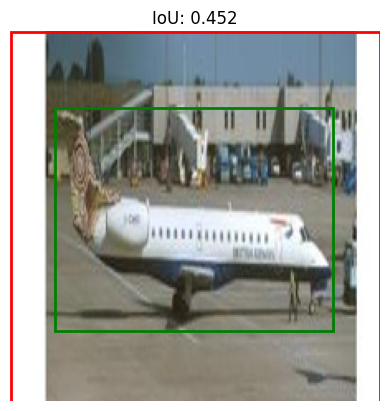

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


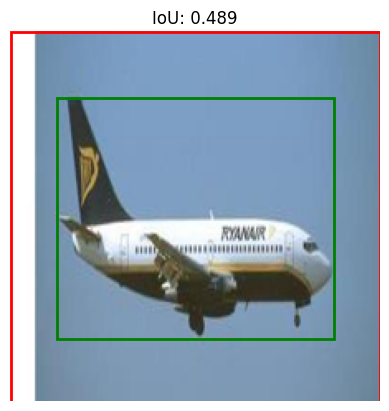

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


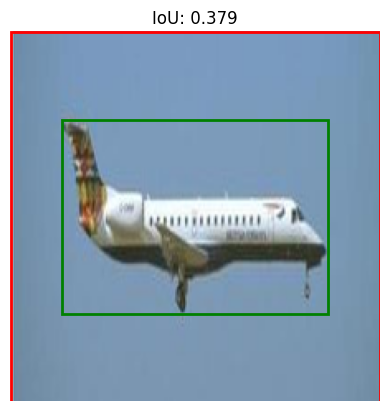

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


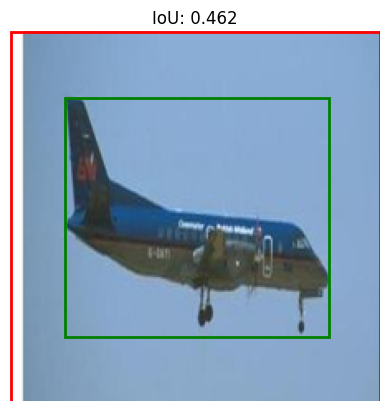

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


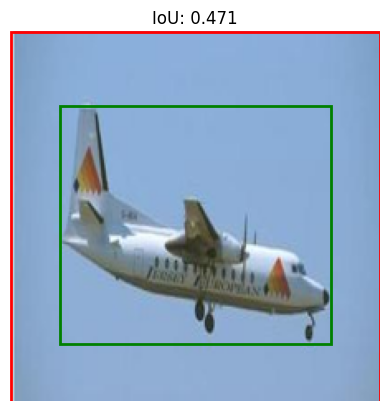

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


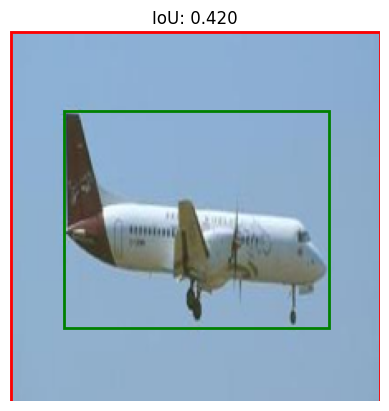

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


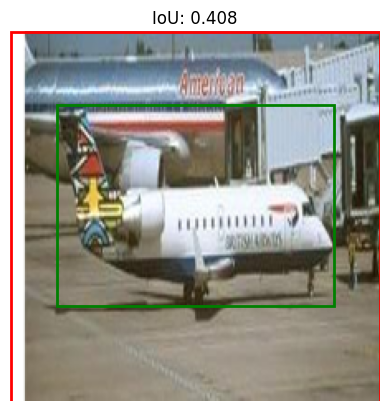

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


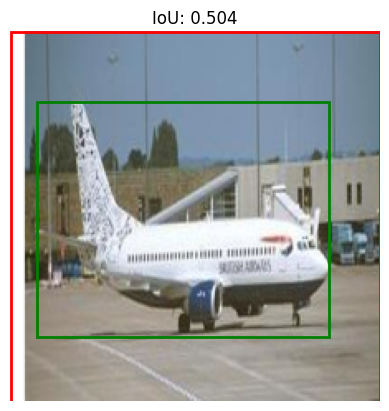

Mean IoU: 0.45247528698077816


In [28]:
# =========================
# BLOCK 13: TRAIN + EVALUATE
# =========================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2

# -------------------------
# 1. CREATE MODEL
# -------------------------
input_shape = (224, 224, 3)

image_size = 224
patch_size = 32
num_patches = (image_size // patch_size) ** 2

model = create_vit_object_detector(
    input_shape=input_shape,
    patch_size=patch_size,
    num_patches=num_patches,
    projection_dim=64,
    num_heads=4,
    transformer_units=[128, 64],
    transformer_layers=4,
    mlp_head_units=[2048, 1024, 512, 64, 32],
)

print("Model created successfully!")

# -------------------------
# 2. TRAIN MODEL
# -------------------------
history = run_experiment(
    model,
    learning_rate=0.001,
    weight_decay=1e-4,
    batch_size=32,
    num_epochs=50
)

# -------------------------
# 3. PLOT LOSS CURVE
# -------------------------
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# -------------------------
# 4. IOU FUNCTION
# -------------------------
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)

    box1_area = (box1[2]-box1[0]) * (box1[3]-box1[1])
    box2_area = (box2[2]-box2[0]) * (box2[3]-box2[1])

    return inter_area / (box1_area + box2_area - inter_area + 1e-6)

# -------------------------
# 5. VISUALIZE PREDICTIONS
# -------------------------
mean_iou = 0

for i in range(10):

    img = x_test[i]

    # Model prediction
    pred = model.predict(np.expand_dims(img, axis=0))[0]

    # Ground truth
    gt = y_test[i]

    h, w = img.shape[:2]

    # Convert normalized → pixel values
    pred_box = [
        int(pred[0] * w),
        int(pred[1] * h),
        int(pred[2] * w),
        int(pred[3] * h)
    ]

    gt_box = [
        int(gt[0] * w),
        int(gt[1] * h),
        int(gt[2] * w),
        int(gt[3] * h)
    ]

    # IoU calculation
    score = iou(pred_box, gt_box)
    mean_iou += score

    # -------------------------
    # Plot image
    # -------------------------
    fig, ax = plt.subplots(1)

    ax.imshow(img.astype("uint8"))

    # Predicted box (RED)
    rect1 = patches.Rectangle(
        (pred_box[0], pred_box[1]),
        pred_box[2] - pred_box[0],
        pred_box[3] - pred_box[1],
        linewidth=2,
        edgecolor="red",
        facecolor="none",
        label="Prediction"
    )

    # Ground truth box (GREEN)
    rect2 = patches.Rectangle(
        (gt_box[0], gt_box[1]),
        gt_box[2] - gt_box[0],
        gt_box[3] - gt_box[1],
        linewidth=2,
        edgecolor="green",
        facecolor="none",
        label="Ground Truth"
    )

    ax.add_patch(rect1)
    ax.add_patch(rect2)

    plt.title(f"IoU: {score:.3f}")
    plt.axis("off")
    plt.show()

# -------------------------
# 6. FINAL SCORE
# -------------------------
print("Mean IoU:", mean_iou / 10)
